# 00 Data audit — exploration

Guide step: **Getting Started → 1. Data Exploration** in `Hackathon2026/CORN_BREEDING_DATA_GUIDE.md`.

This notebook stays on the smaller tables:

1. Load environment and phenotype files (no SNP files yet).
2. Map the year–location trial network.
3. Check trait distributions and missing-data patterns.

Column names in the CSVs do not match the guide. Loaders in `src/data_io.py` rename `YEAR_x` → `YEAR` and strip the BOM on the environment `YEAR` column.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd

REPO_ROOT = Path.cwd().resolve()
if REPO_ROOT.name == "notebooks":
    REPO_ROOT = REPO_ROOT.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from src.data_io import (
    TRAIT_COLS,
    load_environment,
    load_phenotype,
    year_location_keys,
)

pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 120)

OUTPUT_DIR = REPO_ROOT / "outputs" / "data_audit"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print(REPO_ROOT)

/Users/ajaydeep/Desktop/breedforward-ai-ag-2026


## 1. Load environment and phenotype data

The guide says to start here because these files are much smaller than the stacked genome CSVs.

In [2]:
env = load_environment()
pheno_c1 = load_phenotype(1)
pheno_c2 = load_phenotype(2)
pheno = pd.concat(
    [pheno_c1, pheno_c2],
    ignore_index=True,
    sort=False,
)

inventory = pd.DataFrame(
    {
        "table": ["environment", "phenotype_C1", "phenotype_C2", "phenotype_both"],
        "rows": [len(env), len(pheno_c1), len(pheno_c2), len(pheno)],
        "cols": [env.shape[1], pheno_c1.shape[1], pheno_c2.shape[1], pheno.shape[1]],
    }
)
inventory

,table,rows,cols
0,environment,1185,86
1,phenotype_C1,536936,37
2,phenotype_C2,535340,37
3,phenotype_both,1072276,40


In [3]:
print("Environment columns:")
print(list(env.columns))
print("\nPhenotype C1 columns:")
print(list(pheno_c1.columns))

Environment columns:
['YEAR', 'LOC', 'X04_PRCP', 'X05_PRCP', 'X06_PRCP', 'X07_PRCP', 'X08_PRCP', 'X09_PRCP', 'X10_PRCP', 'X04_TAVG', 'X05_TAVG', 'X06_TAVG', 'X07_TAVG', 'X08_TAVG', 'X09_TAVG', 'X10_TAVG', 'X04_DP01', 'X05_DP01', 'X06_DP01', 'X07_DP01', 'X08_DP01', 'X09_DP01', 'X10_DP01', 'X04_DP10', 'X05_DP10', 'X06_DP10', 'X07_DP10', 'X08_DP10', 'X09_DP10', 'X10_DP10', 'X04_HTDD', 'X05_HTDD', 'X06_HTDD', 'X07_HTDD', 'X08_HTDD', 'X09_HTDD', 'X10_HTDD', 'X04_CLDD', 'X05_CLDD', 'X06_CLDD', 'X07_CLDD', 'X08_CLDD', 'X09_CLDD', 'X10_CLDD', 'cfvo_0_5cm', 'cfvo_5_15cm', 'cfvo_15_30cm', 'cfvo_30_60cm', 'cfvo_60_100cm', 'cfvo_100_200cm', 'clay_0_5cm', 'clay_5_15cm', 'clay_15_30cm', 'clay_30_60cm', 'clay_60_100cm', 'clay_100_200cm', 'silt_0_5cm', 'silt_5_15cm', 'silt_15_30cm', 'silt_30_60cm', 'silt_60_100cm', 'silt_100_200cm', 'nitrogen_0_5cm', 'nitrogen_5_15cm', 'nitrogen_15_30cm', 'nitrogen_30_60cm', 'nitrogen_60_100cm', 'nitrogen_100_200cm', 'sand_0_5cm', 'sand_5_15cm', 'sand_15_30cm', 'sand_

## 2. Year–location structure

One environment record should exist per year × location. Many lines are tested inside that cell. 2008 rows are already in the phenotype files; the challenge is a January 2008 decision, so treat 2008 as the future when modeling.

In [4]:
def year_location_summary(df, name):
    keys = year_location_keys(df).dropna()
    return pd.Series(
        {
            "table": name,
            "years": ", ".join(map(str, sorted(df["YEAR"].dropna().unique()))),
            "n_years": df["YEAR"].nunique(dropna=True),
            "n_locations": df["LOC"].nunique(dropna=True),
            "n_year_loc": keys.nunique(),
            "n_rows": len(df),
        }
    )

structure = pd.DataFrame(
    [
        year_location_summary(env, "environment"),
        year_location_summary(pheno_c1, "phenotype_C1"),
        year_location_summary(pheno_c2, "phenotype_C2"),
        year_location_summary(pheno, "phenotype_both"),
    ]
)
structure

,table,years,n_years,n_locations,n_year_loc,n_rows
0,environment,"2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007...",9,405,1185,1185
1,phenotype_C1,"2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007...",9,405,1185,536936
2,phenotype_C2,"2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007...",9,390,1090,535340
3,phenotype_both,"2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007...",9,432,1394,1072276


In [5]:
def plots_by_year(df, cluster_label):
    out = (
        df.groupby("YEAR", dropna=False)
        .agg(
            n_plots=("LOC", "size"),
            n_locations=("LOC", "nunique"),
            n_year_loc=("LOC", "nunique"),
            n_lines=("LINE_UNIQUE_ID", "nunique"),
            n_populations=("population", "nunique"),
        )
        .reset_index()
    )
    out.insert(0, "cluster", cluster_label)
    return out

by_year = pd.concat(
    [plots_by_year(pheno_c1, 1), plots_by_year(pheno_c2, 2)],
    ignore_index=True,
)
by_year

,cluster,YEAR,n_plots,n_locations,n_year_loc,n_lines,n_populations
0,1,2000,32097,102,102,4723,26
1,1,2001,42057,110,110,5924,34
2,1,2002,39724,116,116,6596,41
3,1,2003,91135,132,132,12596,74
4,1,2004,105673,159,159,13553,76
5,1,2005,81488,132,132,11807,68
6,1,2006,64708,145,145,9274,58
7,1,2007,40107,136,136,6160,51
8,1,2008,39947,153,153,7432,71
9,2,2000,17501,74,74,2598,15


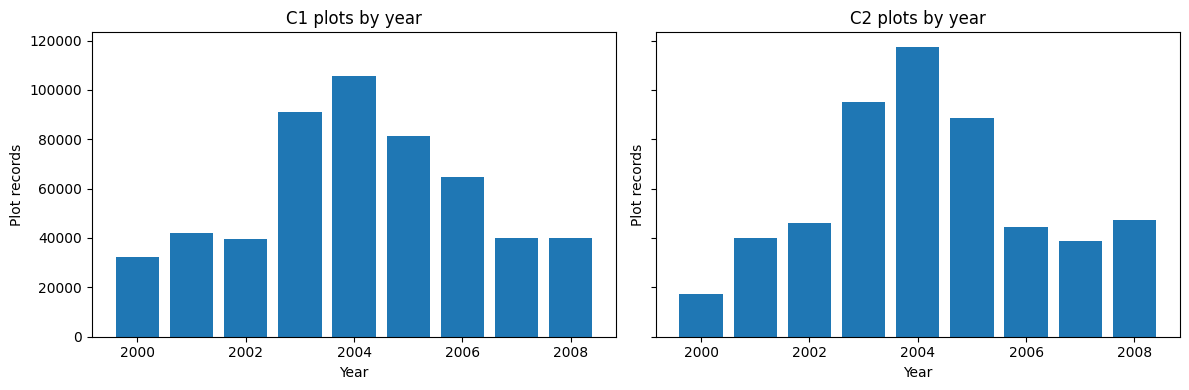

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for ax, cluster, data in zip(axes, [1, 2], [pheno_c1, pheno_c2]):
    counts = data.groupby("YEAR").size()
    ax.bar(counts.index.astype(int), counts.values)
    ax.set_title(f"C{cluster} plots by year")
    ax.set_xlabel("Year")
    ax.set_ylabel("Plot records")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "plots_by_year.png", dpi=120)
plt.show()

In [7]:
pheno_keys = set(year_location_keys(pheno).dropna())
env_keys = set(year_location_keys(env).dropna())

coverage = pd.Series(
    {
        "pheno_year_loc": len(pheno_keys),
        "env_year_loc": len(env_keys),
        "in_both": len(pheno_keys & env_keys),
        "pheno_only": len(pheno_keys - env_keys),
        "env_only": len(env_keys - pheno_keys),
    },
    name="count",
)
coverage

pheno_year_loc    1394
env_year_loc      1185
in_both           1185
pheno_only         209
env_only             0
Name: count, dtype: int64

In [8]:
pheno = pheno.assign(_year_loc=year_location_keys(pheno))
env_key_set = set(year_location_keys(env).dropna())
pheno["has_environment"] = pheno["_year_loc"].isin(env_key_set)

env_match = (
    pheno.groupby("CLUSTER")["has_environment"]
    .agg(n_plots="size", n_with_env="sum", pct_with_env="mean")
    .reset_index()
)
env_match["pct_with_env"] = (env_match["pct_with_env"] * 100).round(2)
env_match

,CLUSTER,n_plots,n_with_env,pct_with_env
0,1,536936,536936,100.00
1,2,535340,482928,90.21


## 3. Trait distributions and missing data

Yield (`YLD_BE`) is the decision trait. Moisture, height, lodging, and test weight are agronomic constraints, not extra targets for the first pass.

In [9]:
present_traits = [col for col in TRAIT_COLS if col in pheno.columns]

missing = (
    pheno.groupby("CLUSTER")[present_traits]
    .apply(lambda d: d.isna().mean() * 100)
    .T.round(2)
)
missing.columns = [f"C{int(c)} missing %" for c in missing.columns]
missing["overall missing %"] = (pheno[present_traits].isna().mean() * 100).round(2)
missing

,C1 missing %,C2 missing %,overall missing %
ERM,42.60,38.10,40.35
MST,2.63,2.84,2.74
PHT,70.92,71.18,71.05
RTLP,56.88,53.58,55.23
STLP,31.94,36.03,33.98
TWT,11.87,12.48,12.18
YLD_BE,3.89,4.36,4.13
EHT,77.91,77.17,77.54


In [10]:
key_missing = pd.DataFrame(
    {
        "C1 missing %": pheno_c1[["YEAR", "LOC", "LINE_UNIQUE_ID", "population"]].isna().mean() * 100,
        "C2 missing %": pheno_c2[["YEAR", "LOC", "LINE_UNIQUE_ID", "population"]].isna().mean() * 100,
    }
).round(2)
key_missing

,C1 missing %,C2 missing %
YEAR,0.0,0.0
LOC,0.0,0.0
LINE_UNIQUE_ID,0.0,0.0
population,0.0,0.0


In [11]:
trait_summary = (
    pheno.groupby("CLUSTER")[present_traits]
    .agg(["count", "mean", "std", "min", "median", "max"])
    .round(2)
)
trait_summary

ERM                                          MST                                     PHT                \
          count    mean   std    min  median     max   count   mean   std   min median   max   count   mean    std   
CLUSTER                                                                                                              
1        308217  107.85  7.96  45.50  109.42  383.50  522826  19.46  4.12  8.10   19.0  44.4  156164  95.23  10.88   
2        331368  107.54  6.89 -24.31  109.01  245.71  520111  19.61  4.13  8.22   19.2  49.5  154281  95.09  11.52   

                               RTLP        ...   STLP              TWT                                  YLD_BE  \
          min median    max   count  mean  ... median      max   count   mean   std   min median   max   count   
CLUSTER                                    ...                                                                   
1        53.0   95.0  150.0  231552  3.18  ...   1.28  3055.56  473207  56.76  2.65  40.1  56.83  70.0  516032   
2        48.0   95.0  148.0  248495  4.72  ...   0.00   140.28  468517  56.41  2.72  40.0  56.53  69.9  511983   

                                                  EHT                                  
           mean    std    min  median     max   count   mean   std   min median   max  
CLUSTER                                                                                
1        193.29  35.75  30.23  195.87  342.57  118587  43.99  7.09  14.0   44.0  76.0  
2        196.75  36.19  26.87  198.91  329.40  122197  43.90  7.04  17.0   44.0  70.0  

[2 rows x 48 columns]

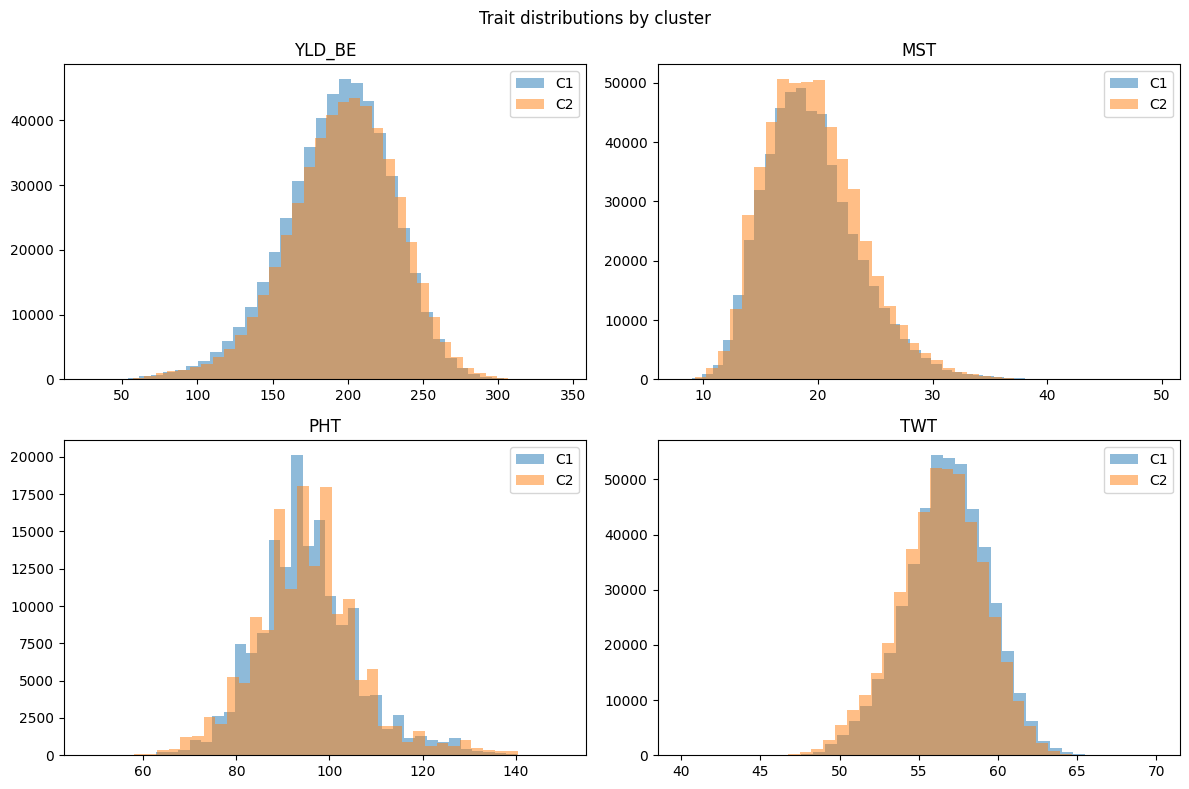

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, col in zip(axes.ravel(), ["YLD_BE", "MST", "PHT", "TWT"]):
    for cluster, data in [(1, pheno_c1), (2, pheno_c2)]:
        ax.hist(data[col].dropna(), bins=40, alpha=0.5, label=f"C{cluster}")
    ax.set_title(col)
    ax.legend()
fig.suptitle("Trait distributions by cluster")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "trait_distributions.png", dpi=120)
plt.show()

In [13]:
yield_by_year = (
    pheno.groupby(["CLUSTER", "YEAR"])["YLD_BE"]
    .agg(n="count", mean="mean", std="std")
    .round(2)
    .reset_index()
)
yield_by_year

,CLUSTER,YEAR,n,mean,std
0,1,2000,31470,166.00,30.00
1,1,2001,40929,183.51,33.50
2,1,2002,38399,180.90,37.62
3,1,2003,87085,180.37,35.65
4,1,2004,99660,208.39,32.85
5,1,2005,79682,199.65,30.72
6,1,2006,62902,195.62,33.56
7,1,2007,38383,199.17,36.25
8,1,2008,37522,205.92,30.39
9,2,2000,16903,168.61,28.94


In [14]:
ids = pd.DataFrame(
    [
        {
            "cluster": cluster,
            "n_plots": len(df),
            "n_lines": df["LINE_UNIQUE_ID"].nunique(),
            "n_populations": df["population"].nunique(),
            "unparsed_ids": int(df["population"].isna().sum()),
            "n_testers": df["GERMPLASM_ID_TESTER"].nunique(dropna=True)
            if "GERMPLASM_ID_TESTER" in df.columns
            else pd.NA,
        }
        for cluster, df in [(1, pheno_c1), (2, pheno_c2)]
    ]
)
ids

,cluster,n_plots,n_lines,n_populations,unparsed_ids,n_testers
0,1,536936,78065,499,0,54
1,2,535340,76635,500,0,44


In [15]:
id_formats = pd.DataFrame(
    [
        {
            "cluster": cluster,
            "example_id": df["LINE_UNIQUE_ID"].iloc[0],
            "parsed_pct": (df["population"].notna().mean() * 100).round(2),
            "n_populations": int(df["population"].nunique()),
            "n_with_suffix": int(df["id_suffix"].notna().sum()),
            "suffix_examples": ", ".join(
                df["id_suffix"].dropna().astype(str).value_counts().head(5).index
            ),
        }
        for cluster, df in [(1, pheno_c1), (2, pheno_c2)]
    ]
)
id_formats

,cluster,example_id,parsed_pct,n_populations,n_with_suffix,suffix_examples
0,1,C1.1.191,100.0,499,4488,".1, #1, .2, #2, DS%69"
1,2,C2.1.1.0,100.0,500,535340,".0, .1"


## Exploration notes

- Phenotype files include **2000 and 2008**, not only 2001–2008. Hold out 2008 later.
- Raw phenotype year is `YEAR_x`; the loader standardizes it to `YEAR`.
- Environment columns are monthly (`X04_PRCP`) and depth-specific soil, not `PRCP_1`.
- C1 IDs are mostly `C1.{pop}.{line}`. C2 IDs are `C2.{pop}.{line}.{extra}` (often `.0`). The loader now parses both.
- Every C1 plot has an environment row. About 10% of C2 plots do not.
- Yield is almost complete; plant/ear height and lodging are not.
- Next guide step: **quality control** on join keys, coordinates, and genomic completeness.